In [112]:
# import necessary modules for analysis
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

In [113]:
# preset matplotlib parameters for better plots
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300

In [114]:
# import the data as a dataframe, then assign datetime object
ecomm = pd.read_csv("unidentified_ecom_data.csv")
ecomm["datetime"] = pd.to_datetime(ecomm["order_date_dt"], format = "mixed")
# display the top 10 rows for show
ecomm.head(10)

,subtotal,order_date_dt,order_total_revenue,zip_code,unique_customer_id,datetime
0,40.0,2024-08-17,24.0,NaN,1,2024-08-17
1,75.0,2024-08-17,40.0,NaN,2,2024-08-17
2,300.0,2024-08-14,200.0,80027.0,3,2024-08-14
3,40.0,2024-08-02,24.0,89122.0,4,2024-08-02
4,150.0,2024-08-02,100.0,81657.0,5,2024-08-02
5,150.0,2024-08-01,100.0,NaN,6,2024-08-01
6,80.0,2024-08-01,56.0,NaN,7,2024-08-01
7,80.0,2024-08-01,56.0,NaN,7,2024-08-01
8,80.0,2024-08-01,56.0,NaN,7,2024-08-01
9,80.0,2024-08-01,56.0,NaN,7,2024-08-01


In [115]:
# as a quick test, let's greate a groupby by date to see daily
# revenue mapped over time
daily_purchase = ecomm.groupby("datetime")["order_total_revenue"].sum().reset_index()
# display the top 4 of this new grouping
daily_purchase.head(5)

,datetime,order_total_revenue
0,2021-11-26,12.99
1,2021-12-06,81.99
2,2021-12-07,722.91
3,2021-12-11,1610.00
4,2021-12-12,300.00


In [116]:
average_daily_revenue = daily_purchase["order_total_revenue"].mean().round(2)
med_daily_revenue = daily_purchase["order_total_revenue"].median()
print(f"""
The average daily revenue for this small ecomm business is:
{average_daily_revenue}
With a median daily revenue as:
{med_daily_revenue}
""")


The average daily revenue for this small ecomm business is:
157.55
With a median daily revenue as:
92.4



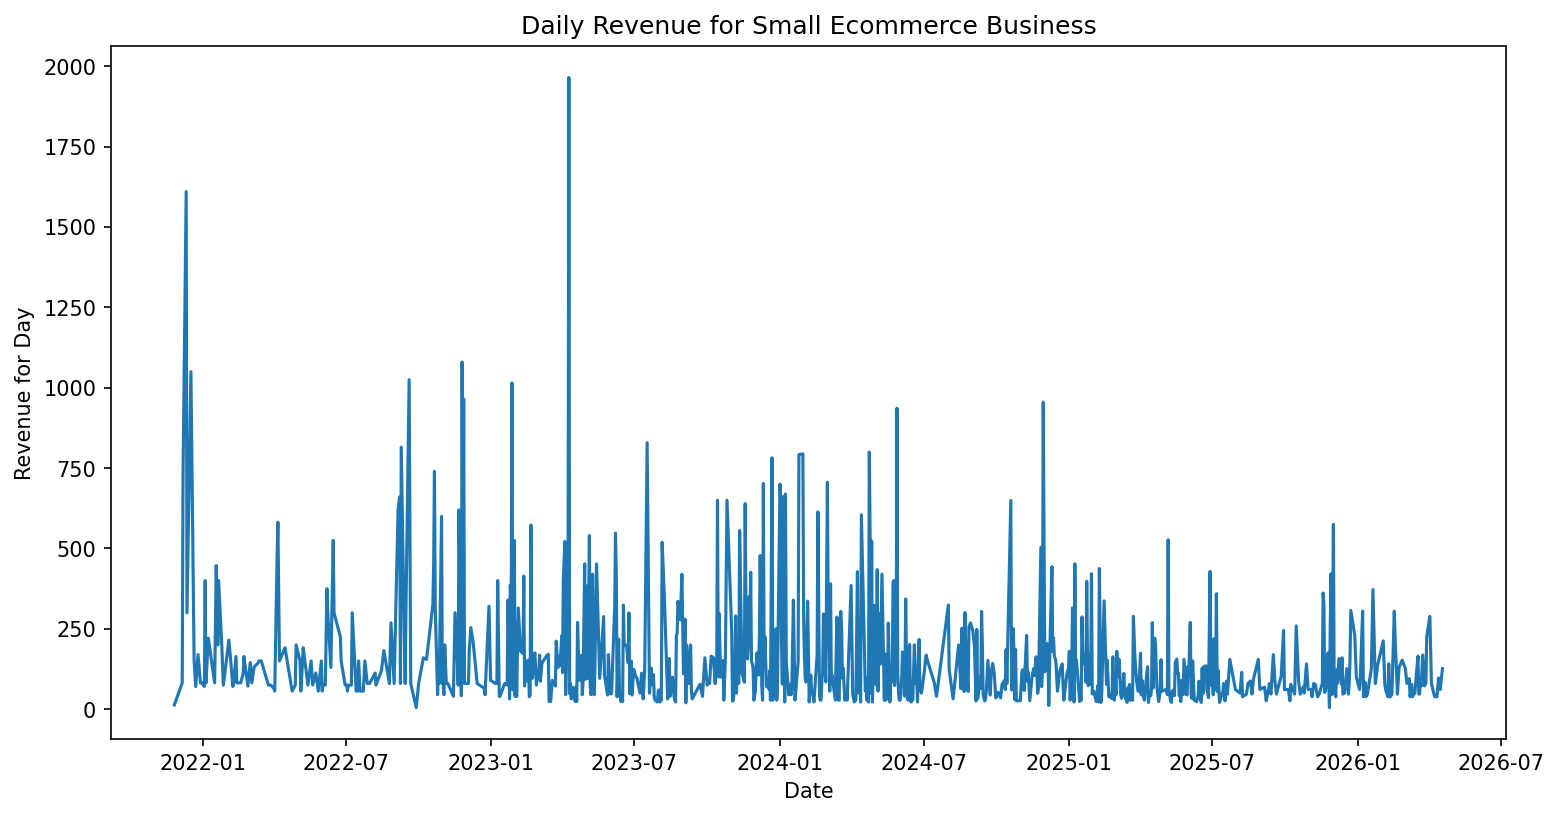

In [117]:
# plot the data above
plt.plot(daily_purchase["datetime"], 
         daily_purchase["order_total_revenue"])
plt.xlabel("Date")
plt.ylabel("Revenue for Day")
plt.title("Daily Revenue for Small Ecommerce Business")
plt.show()

In [118]:
# display the first order and the last order
first_order = ecomm["datetime"].min()
latest_order = ecomm["datetime"].max()
time_diff = (latest_order - first_order)
days_total = time_diff.days

# floor division operator; only take full years
years = days_total // 365
# modulus operator, take what's left over in days
# divide by 30
months = (days_total % 365) // 30
days = (days_total % 365) % 30

print(f"The first order in this dataset was placed {first_order}")
print("")
print(f"The latest order in this dataset was placed {latest_order}")
print(f"""
Meaning this dataset spans approx. 
{years} years, {months} months, and {days} days of sales data.
""")

The first order in this dataset was placed 2021-11-26 00:00:00

The latest order in this dataset was placed 2026-04-18 00:00:00

Meaning this dataset spans approx. 
4 years, 4 months, and 24 days of sales data.



In [119]:
# next we will figure out average spend for customer in a lifetime
person_purchase = ecomm.groupby("unique_customer_id")["order_total_revenue"].sum().reset_index()

highest_purchaser = person_purchase["order_total_revenue"].max()
lowest_purchaser = person_purchase["order_total_revenue"].min()
print(highest_purchaser)
print(lowest_purchaser)

3670.9
11.6


## Prepare Monetary and Frequency Data

In [120]:
# here, let's do some equations to build the dataset we
# can runt the RFM off of. First, we want to group by unique
# customer id. Then we want their total revenue.
# we also want a list of all of the dates that each customer
# purchased so we can do recency and frequency.
customer_summary = (
    ecomm.groupby("unique_customer_id")
      .agg({
          "order_total_revenue": "sum",
          "datetime": list
      })
      .reset_index()
)

customer_summary["num_orders"] = customer_summary["datetime"].apply(len)
customer_summary["latest_order"] = customer_summary["datetime"].apply(max)

## Prepare Recency Data

In [123]:
# establish todays date to get a recency number
# smaller recency number = more recent (less days since last purchase)
today = pd.Timestamp.today()
customer_summary["days_last_purchase"] = (
    today - customer_summary["latest_order"]
).dt.days


In [124]:
customer_summary.head()

,unique_customer_id,order_total_revenue,datetime,num_orders,latest_order,days_since_last_purchase,days_last_purchase
0,1,144.00,"[2024-08-17 00:00:00, 2024-05-27 00:00:00, 202...",3,2024-08-29,608,608
1,2,136.25,"[2024-08-17 00:00:00, 2024-07-17 00:00:00, 202...",3,2024-08-17,620,620
2,3,760.80,"[2024-08-14 00:00:00, 2024-06-25 00:00:00, 202...",6,2025-11-28,152,152
3,4,440.00,"[2024-08-02 00:00:00, 2024-07-02 00:00:00, 202...",19,2025-05-19,345,345
4,5,422.00,"[2024-08-02 00:00:00, 2024-03-21 00:00:00, 202...",4,2024-08-02,635,635


## Assign Recency Score

In [126]:
# here, we will break the data into quintiles based on the
# days since the last purchase and assign to `recency_score`
customer_summary["recency_score"] = pd.qcut(
    customer_summary["days_last_purchase"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

## Assign Frequency Score

In [141]:
# we tried to split into even quintiles, but so
# many customers had only one order that it was
# impossible to break into even groups. So instead
# we broke into sections based on how many orders the
# customer has made
def frequency_score(x):
    if x == 1:
        return 1
    elif x == 2:
        return 2
    elif x == 3:
        return 3
    elif x == 4:
        return 4
    else:
        return 5

customer_summary["frequency_score"] = customer_summary["num_orders"].apply(frequency_score)

## Assign Monetary Score

In [143]:
# now we will use a similar function using pandas.qcut to
# break it into quintiles based on total revenue
customer_summary["monetary_score"] = pd.qcut(
    customer_summary["order_total_revenue"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

## Combine to Make RFM Codes

In [150]:
# here we are going to turn the scores into strings then
# combine them to give an RFM code for each participant.
customer_summary["rfm_code"] = (
    customer_summary["recency_score"].astype(str) +
    customer_summary["frequency_score"].astype(str) +
    customer_summary["monetary_score"].astype(str)
)

In [151]:
customer_summary

,unique_customer_id,order_total_revenue,datetime,num_orders,latest_order,days_since_last_purchase,days_last_purchase,recency_score,frequency_score,monetary_score,rfm_code
0,1,144.00,"[2024-08-17 00:00:00, 2024-05-27 00:00:00, 202...",3,2024-08-29,608,608,3,3,4,334
1,2,136.25,"[2024-08-17 00:00:00, 2024-07-17 00:00:00, 202...",3,2024-08-17,620,620,3,3,4,334
2,3,760.80,"[2024-08-14 00:00:00, 2024-06-25 00:00:00, 202...",6,2025-11-28,152,152,5,5,5,555
3,4,440.00,"[2024-08-02 00:00:00, 2024-07-02 00:00:00, 202...",19,2025-05-19,345,345,5,5,5,555
4,5,422.00,"[2024-08-02 00:00:00, 2024-03-21 00:00:00, 202...",4,2024-08-02,635,635,3,4,5,345
...,...,...,...,...,...,...,...,...,...,...,...
838,839,55.00,[2024-08-26 00:00:00],1,2024-08-26,611,611,3,1,2,312
839,840,64.00,[2024-08-22 00:00:00],1,2024-08-22,615,615,3,1,3,313
840,841,65.00,[2024-08-22 00:00:00],1,2024-08-22,615,615,3,1,3,313
841,842,55.00,[2024-08-21 00:00:00],1,2024-08-21,616,616,3,1,2,312
